## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
class SimpleNet:

    # Initialise network parameters
    def __init__(self, N):
        self.W = [1] * N
        self.B = [0] * N
        self.A = [1] * N
        self.N = N

    # Forward pass on single value
    def forward(self, x):
        
        # Load network parameters
        W, B, A, N = self.W, self.B, self.A, self.N

        y = 0
        for i in range(N):
            y += A[i] * max(0, W[i] * x + B[i])
            
        return y
    
    # Update network parameters
    def update_weights(self, W = None, B = None, A = None):
        if W is not None:
            self.W = W
        if B is not None:
            self.B = B
        if A is not None:
            self.A = A

    # Plot network for specified range
    def plot(self, start = -10, stop = 10, res = 10):

        # Calculate values for range
        x = np.linspace(start, stop, abs(start) * res + abs(stop) * res + 1)
        y = [self.forward(point) for point in x]

        # Load network parameters
        W, B, A, N = self.W, self.B, self.A, self.N

        # Create title string
        title = f"Network: {N} neuron(s)"
        for i in range(N):
            title += f"\nw{i + 1:2} = {W[i]:3},   b{i + 1:2} = {B[i]:3},   a{i + 1:2} = {A[i]:3}"
        
        # Plot graph
        plt.figure()
        plt.plot(x, y)
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title(title)
        plt.show()

## Single ReLU examples

The default values produce a regular ReLU

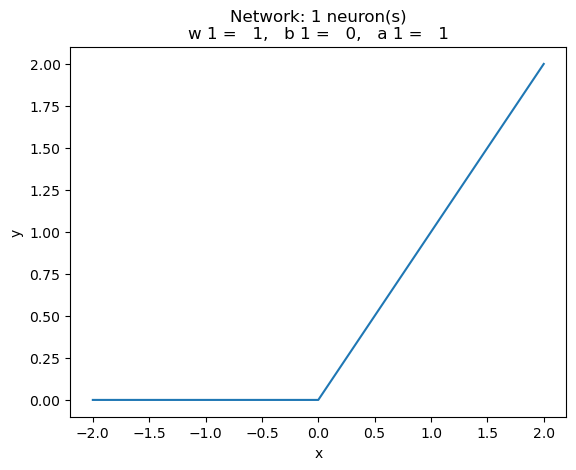

In [15]:
# ReLU function
net = SimpleNet(1)
net.plot(-2, 2)

Flipping the sign of the input weight mirrors the ReLU Horizontally

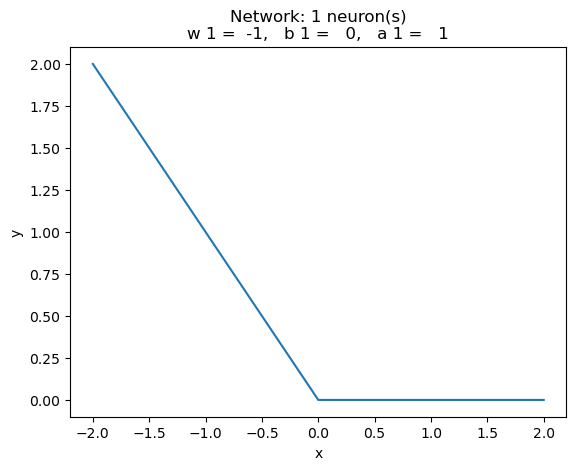

In [ ]:
# Mirrored (H) ReLU function
net = SimpleNet(1)
net.update_weights(
    W = [-1],
)
net.plot(-2, 2)

Flipping the sign of the output weight mirrors the ReLU vertically

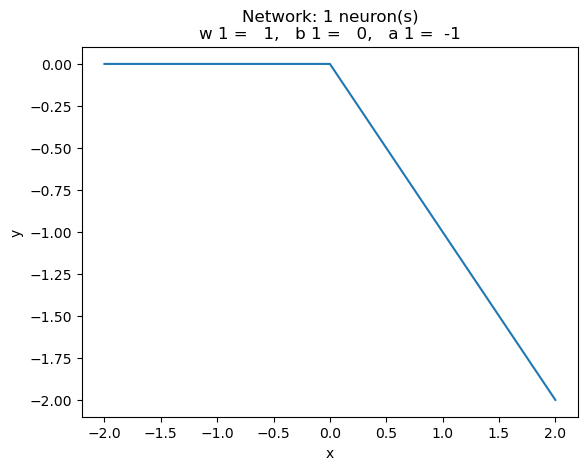

In [17]:
# Mirrored (V) ReLU function
net = SimpleNet(1)
net.update_weights(
    A = [-1],
)
net.plot(-2, 2)

Increasing the bias moves the ReLU to the left

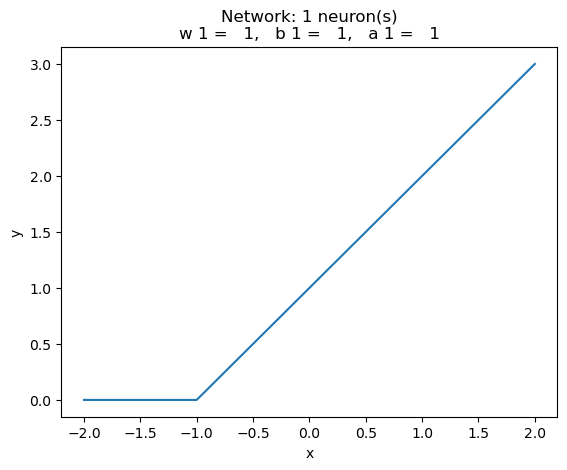

In [ ]:
# Shifted ReLU function
net = SimpleNet(1)
net.update_weights(
    B = [1],
)
net.plot(-2, 2)

The shift from the bias is ALSO mirrored (horizontally)

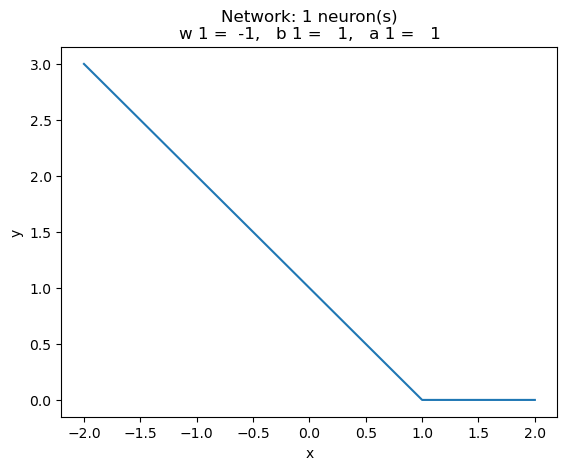

In [19]:
# Shifted mirrored ReLU function
net = SimpleNet(1)
net.update_weights(
    W = [-1],
    B = [1],
)
net.plot(-2, 2)

If you want to mirror only the direction and not the bending point, the sign of both values needs to be flipped

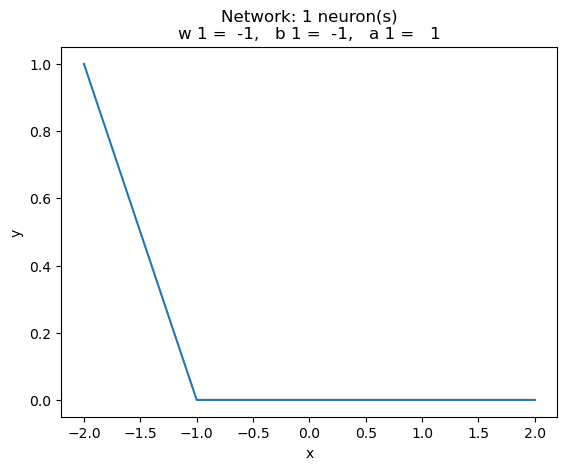

In [20]:
# Shifted mirrored ReLU function
net = SimpleNet(1)
net.update_weights(
    W = [-1],
    B = [-1],
)
net.plot(-2, 2)

The bias can remain unchanged when mirroring vertically

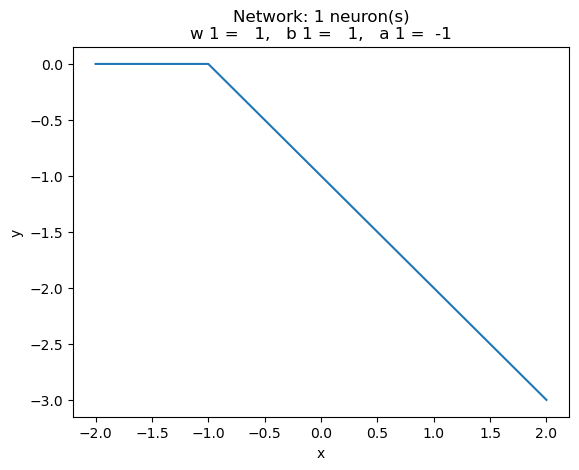

In [21]:
# Shifted ReLU function
net = SimpleNet(1)
net.update_weights(
    B = [1],
    A = [-1],
)
net.plot(-2, 2)

## Multiple ReLU's

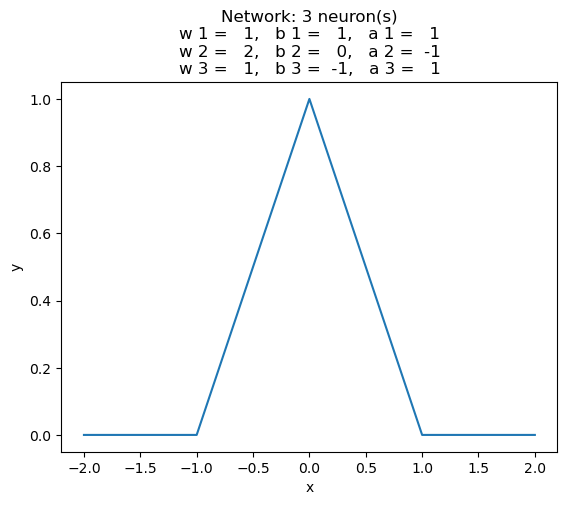

In [14]:
# 3 neuron network
net = SimpleNet(3)

# configure weights & biases
net.update_weights(
    W = [1, 2, 1],
    B = [1, 0, -1],
    A = [1, -1, 1]
)

# plot between -2 and 2
net.plot(-2, 2)

Idea:

Add mutation function to network to:
- Flip direction of a neuron horizontally
- Flip direction of a neuron vertically
- Shift the position of a neuron left or right